# SWYNEX Task 2: Exploratory Data Analysis (Titanic Dataset)

**Goal:** Analyze the cleaned Titanic dataset from Task 1, using statistics and visualizations, and report at least five insights that could influence a model or decision.

**Input:** `cleaned_data.csv` produced in Task 1 (891 rows, 13 columns, 0 missing values).

## 1. Setup and load the cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("cleaned_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 13)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,AgeImputed
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,Southampton,0,0
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,Cherbourg,1,0
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,Southampton,0,0
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,Southampton,1,0
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,Southampton,0,0


## 2. Overall statistics

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891,2,No,549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.112458,13.304352,0.4,21.5,26.0,36.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204366,49.693414,0.0,7.91,14.45,31.0,512.33


In [3]:
survival_rate = (df["Survived"] == "Yes").mean()
print(f"Overall survival rate: {survival_rate:.1%}")

Overall survival rate: 38.4%


## 3. Insight 1: Survival strongly depends on passenger class

Wealthier passengers (1st class) survived at a much higher rate than 3rd class passengers.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


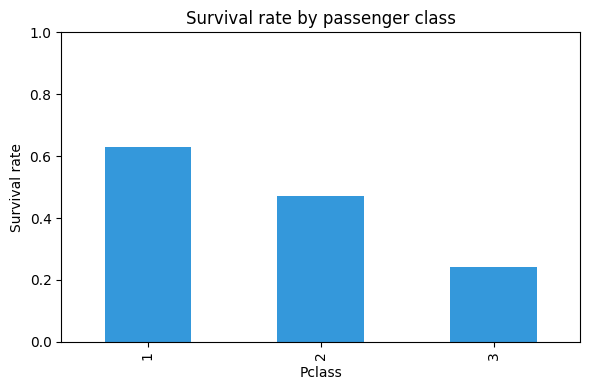

In [4]:
class_survival = df.groupby("Pclass")["Survived"].apply(lambda s: (s == "Yes").mean())
print(class_survival)

fig, ax = plt.subplots(figsize=(6, 4))
class_survival.plot(kind="bar", ax=ax, color="#3498db")
ax.set_title("Survival rate by passenger class")
ax.set_xlabel("Pclass")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("insight1_class_survival.png", dpi=150)
plt.show()

## 4. Insight 2: Sex is the strongest predictor of survival

Women survived at a far higher rate than men, consistent with a "women and children first" evacuation policy.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


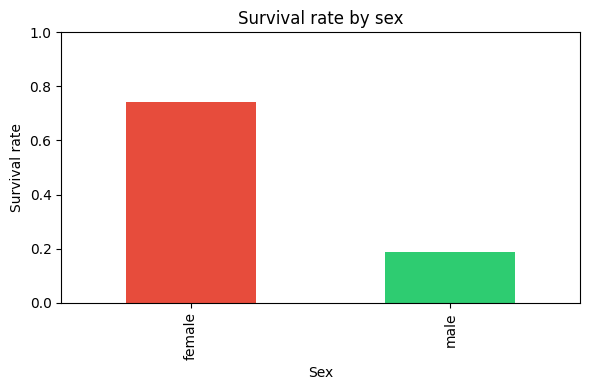

In [5]:
sex_survival = df.groupby("Sex")["Survived"].apply(lambda s: (s == "Yes").mean())
print(sex_survival)

fig, ax = plt.subplots(figsize=(6, 4))
sex_survival.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Survival rate by sex")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("insight2_sex_survival.png", dpi=150)
plt.show()

## 5. Insight 3: Age distribution and its link to survival

Children under about 10 had a noticeably higher survival rate than other age groups.

AgeGroup
0-10     0.593750
11-18    0.426667
19-30    0.321343
31-50    0.428044
51-80    0.343750
Name: Survived, dtype: float64


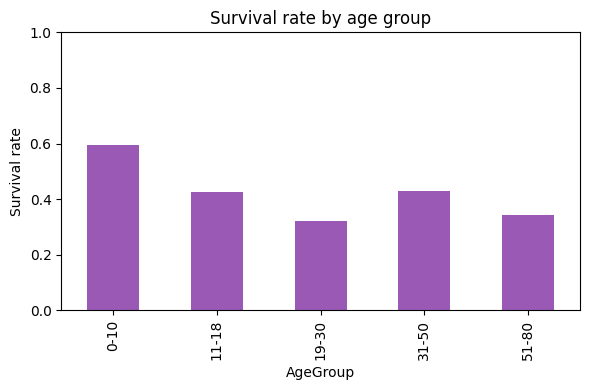

In [6]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 10, 18, 30, 50, 80],
                         labels=["0-10", "11-18", "19-30", "31-50", "51-80"])
age_survival = df.groupby("AgeGroup", observed=True)["Survived"].apply(lambda s: (s == "Yes").mean())
print(age_survival)

fig, ax = plt.subplots(figsize=(6, 4))
age_survival.plot(kind="bar", ax=ax, color="#9b59b6")
ax.set_title("Survival rate by age group")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("insight3_age_survival.png", dpi=150)
plt.show()

## 6. Insight 4: Family size has a "sweet spot"

Passengers travelling completely alone, or in very large families, survived less often than those in small families (2-4 members).

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


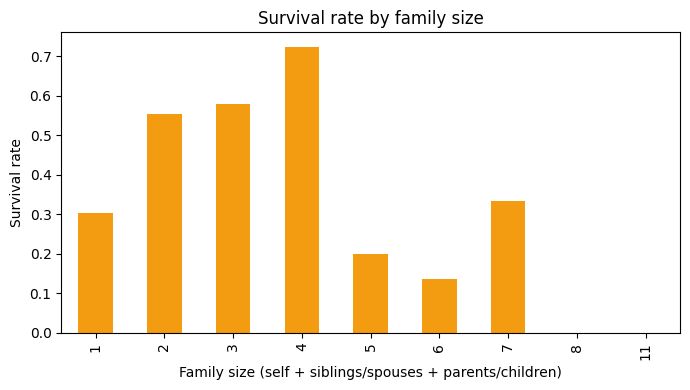

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("FamilySize")["Survived"].apply(lambda s: (s == "Yes").mean())
print(family_survival)

fig, ax = plt.subplots(figsize=(7, 4))
family_survival.plot(kind="bar", ax=ax, color="#f39c12")
ax.set_title("Survival rate by family size")
ax.set_xlabel("Family size (self + siblings/spouses + parents/children)")
ax.set_ylabel("Survival rate")
plt.tight_layout()
plt.savefig("insight4_family_survival.png", dpi=150)
plt.show()

## 7. Insight 5: Fare (and having a recorded cabin) correlate with survival

Passengers who paid higher fares, and those with a recorded cabin, survived more often. This lines up with the class effect in Insight 1, since fare and cabin both track wealth and class.

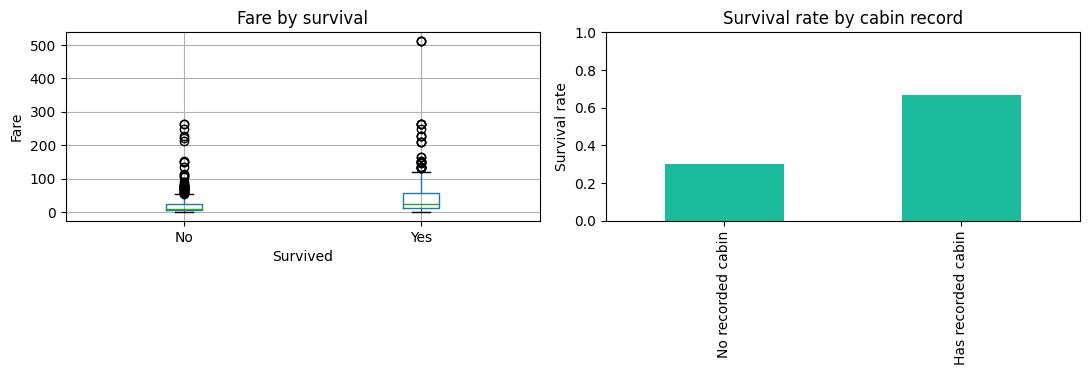

No recorded cabin     0.299854
Has recorded cabin    0.666667
Name: Survived, dtype: float64
Survived
No     10.5
Yes    26.0
Name: Fare, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="Fare", by="Survived", ax=axes[0])
axes[0].set_title("Fare by survival")
axes[0].set_xlabel("Survived")
axes[0].set_ylabel("Fare")
plt.suptitle("")

cabin_survival = df.groupby("HasCabin")["Survived"].apply(lambda s: (s == "Yes").mean())
cabin_survival.index = ["No recorded cabin", "Has recorded cabin"]
cabin_survival.plot(kind="bar", ax=axes[1], color="#1abc9c")
axes[1].set_title("Survival rate by cabin record")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("insight5_fare_cabin_survival.png", dpi=150)
plt.show()

print(cabin_survival)
print(df.groupby("Survived")["Fare"].median())

## 8. Correlation overview

A correlation heatmap of the numeric columns confirms the patterns above: `Pclass` and `Fare` both correlate with survival, and `Pclass` and `Fare` are themselves strongly (negatively) related, as expected.

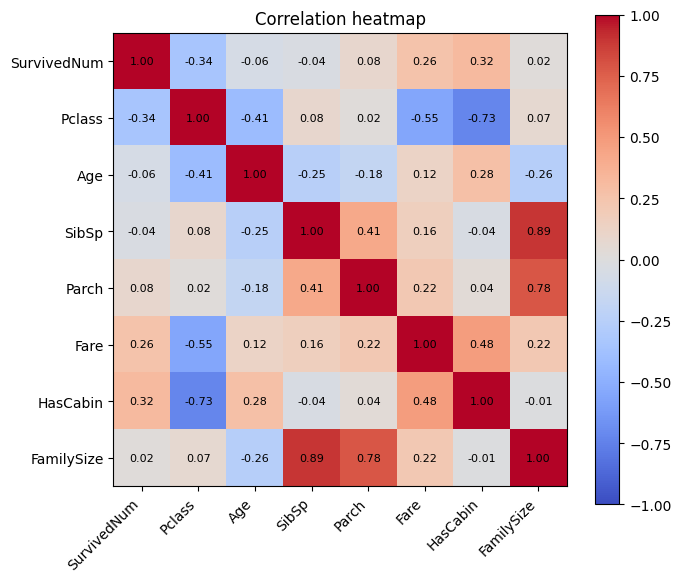

SurvivedNum    1.000000
HasCabin       0.316912
Fare           0.257305
Parch          0.081629
FamilySize     0.016639
SibSp         -0.035322
Age           -0.059576
Pclass        -0.338481
Name: SurvivedNum, dtype: float64

In [9]:
numeric_df = df.copy()
numeric_df["SurvivedNum"] = (numeric_df["Survived"] == "Yes").astype(int)
corr = numeric_df[["SurvivedNum", "Pclass", "Age", "SibSp", "Parch", "Fare", "HasCabin", "FamilySize"]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

corr["SurvivedNum"].sort_values(ascending=False)

## 9. Summary of the five insights

1. **Passenger class matters most after sex.** 1st class passengers survived far more often than 3rd class, reflecting where cabins were located and evacuation priority.
2. **Sex is the single strongest predictor.** Women survived at a much higher rate than men.
3. **Young children had a survival advantage.** The 0-10 age group survived more often than other age groups.
4. **Family size has a sweet spot.** Small families (2-4 people) survived more often than solo travellers or very large families.
5. **Fare and cabin record both track survival**, because they both reflect passenger class and wealth, not because paying more directly caused survival.

**What this means for modelling:** `Sex`, `Pclass`, `Age`, `FamilySize` and `Fare` are the strongest candidate features for a survival prediction model. `Fare` and `Pclass` are correlated, so a model may only need one of them to avoid redundancy.